# Test zavolab_pyutils Module

Testing the `read_count_data_analysis` module with sample data

In [91]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# this is important to be able to re-import the module after making modifications to the zavolab_pyutils code on Scicore

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Create sample count data

In [93]:
from zavolab_pyutils.read_count_simulation import simulate_negative_binomial_counts, simulate_poisson_lognormal_counts

In [94]:
# we generate the data under assumption of NO differentially expressed genes, so any significant changes between conditions are false positives!

In [96]:
# Generate DESeq2-style data (Poisson-Gamma)
nb_counts_10repl_df, metadata_10repl_df, nb_true_10repl_sf = simulate_negative_binomial_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=10, 
    alpha=0.05, # The true variance target
    seed=102,
    SF_sigma=0.3,exp_average_M=4,exp_average_S=3,
)

print("Negative Binomial Counts:")
print(nb_counts_10repl_df.head(2))

Negative Binomial Counts:
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6  Sample_7  \
Gene_1     10991     12729     10981      6152     12525      9413      6650   
Gene_2      1218       744      1516       481       982       648       710   

        Sample_8  Sample_9  Sample_10  Sample_11  Sample_12  Sample_13  \
Gene_1      4704      6397       4741      13100       8189       7404   
Gene_2       649       948        345       1106       1004        788   

        Sample_14  Sample_15  Sample_16  Sample_17  Sample_18  Sample_19  \
Gene_1       5230       6095       8800       4772       9478       4632   
Gene_2        584        578        954        507       1543        625   

        Sample_20  
Gene_1       5701  
Gene_2        996  


In [97]:
nb_true_10repl_sf

array([1.64941468, 1.3201674 , 1.37355055, 0.75873576, 1.47686934,
       1.10445821, 0.85816963, 0.76267013, 0.96174599, 0.51096149,
       1.33903535, 0.99277081, 0.86460863, 0.7169284 , 0.84561388,
       1.36713317, 0.59829053, 1.04168122, 0.86993812, 1.0154115 ])

In [98]:
# Generate DESeq2-style data (Poisson-Gamma)
nb_counts_3repl_df, metadata_3repl_df, nb_true_3repl_sf = simulate_negative_binomial_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=3, 
    alpha=0.05, # The true variance target
    seed=102,
    SF_sigma=0.3,exp_average_M=4,exp_average_S=3,
)

print("Negative Binomial Counts:")
print(nb_counts_3repl_df.head(2))

Negative Binomial Counts:
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6
Gene_1     10991     12729     10981      6152     12525      9413
Gene_2      1351       856      1002       758      1555       978


In [99]:
nb_true_3repl_sf

array([1.64941468, 1.3201674 , 1.37355055, 0.75873576, 1.47686934,
       1.10445821])

In [100]:
# Generate Sanity-style data (Poisson-LogNormal)
pln_counts_3repl_df, metadata_3repl_df, pln_true_3repl_sf = simulate_poisson_lognormal_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=3, 
    v_log=0.05, # The true variance target
    seed=102,
    SF_sigma=0.3,exp_average_M=4,exp_average_S=3,
)

pln_counts_10repl_df, metadata_10repl_df, pln_true_10repl_sf = simulate_poisson_lognormal_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=10, 
    v_log=0.05, # The true variance target
    seed=102,
    SF_sigma=0.3,exp_average_M=4,exp_average_S=3,
)
print("\nPoisson-LogNormal Counts:")
print(pln_counts_3repl_df.head(2))

print(pln_counts_10repl_df.head(2))


Poisson-LogNormal Counts:
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6
Gene_1     11362     13119     13872      6525     17332      4446
Gene_2      1327       813      1236       542      1025      1161
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6  Sample_7  \
Gene_1     11362     13119     13872      6525     17332      4446      6399   
Gene_2      2165       898      1079       727       922       708      1173   

        Sample_8  Sample_9  Sample_10  Sample_11  Sample_12  Sample_13  \
Gene_1      4380      7831       3336       8887       9498       6466   
Gene_2       507       717        434       1609        668        813   

        Sample_14  Sample_15  Sample_16  Sample_17  Sample_18  Sample_19  \
Gene_1       5767       6918      14149       4315       8466       6402   
Gene_2        670        724       1181        674        987        625   

        Sample_20  
Gene_1       6653  
Gene_2       1055  


In [101]:
pln_true_3repl_sf

array([1.64941468, 1.3201674 , 1.37355055, 0.75873576, 1.47686934,
       1.10445821])

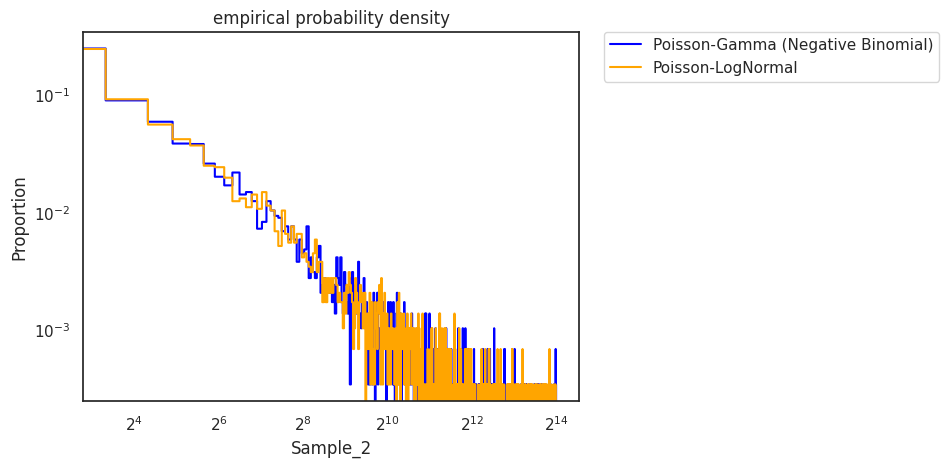

In [102]:
ax = sns.histplot(nb_counts_3repl_df['Sample_2']+1,stat="proportion",bins=range(0,2**14,10),color='blue',label='Poisson-Gamma (Negative Binomial)',element="step", fill=False)
ax = sns.histplot(pln_counts_3repl_df['Sample_2']+1,stat="proportion",bins=range(0,2**14,10),color='orange',label='Poisson-LogNormal',element="step", fill=False)
ax.set_xscale('log', base=2)
ax.set_yscale('log', base=10)
ax.set(title='empirical probability density')
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc=2,
    borderaxespad=0.0,
    title='',
    markerscale=1,
    ncol=1,
)

## DESeq2-style normalization and quantification

In [103]:
from zavolab_pyutils.read_count_data_analysis import apply_deseq2_normalization, model_mean_variance

In [104]:
# Apply normalization
norm_counts_3repl_df, sfs_3repl_df = apply_deseq2_normalization(
    nb_counts_3repl_df, 
    metadata_3repl_df,
    lowExprGenesQ=0.3,
    pseudocount=1
)

norm_counts_10repl_df, sfs_10repl_df = apply_deseq2_normalization(
    nb_counts_10repl_df, 
    metadata_10repl_df,
    lowExprGenesQ=0.3,
    pseudocount=1
)

print("Normalized count matrix:")
print(norm_counts_3repl_df.head(2))
print(f"\nShape: {norm_counts_3repl_df.shape}")

Normalized count matrix:
           Sample_1      Sample_2     Sample_3     Sample_4      Sample_5  \
Gene_1  8178.106000  11875.592759  9836.477056  9886.542347  10441.867457   
Gene_2  1005.895134    799.480204   898.377935  1219.549105   1297.105681   

            Sample_6  
Gene_1  10590.287879  
Gene_2   1101.326942  

Shape: (3000, 6)


In [105]:
print("Size factors and read metrics:")
print(sfs_3repl_df[["sf", "log2_sf", "read_sum", "read_sum_mln"]])

Size factors and read metrics:
                sf   log2_sf  read_sum  read_sum_mln
sample                                              
Sample_1  1.344076  0.426615  24275349         24.28
Sample_2  1.071946  0.100233  17251615         17.25
Sample_3  1.116457  0.158927  20383148         20.38
Sample_4  0.622361 -0.684176   9918839          9.92
Sample_5  1.199594  0.262546  18959106         18.96
Sample_6  0.888928 -0.169862  14721419         14.72


### Verify normalization

Check that the median size factor is close to 1 (expected behavior after normalization)

In [106]:
print('for 3 bioreplicates per condition:')
print(f"Median size factor: {sfs_10repl_df['sf'].median():.3f}")
print(f"Mean size factor: {sfs_10repl_df['sf'].mean():.3f}")
print('\nfor 10 bioreplicates per condition:')
print(f"Median size factor: {sfs_3repl_df['sf'].median():.3f}")
print(f"Mean size factor: {sfs_3repl_df['sf'].mean():.3f}")

for 3 bioreplicates per condition:
Median size factor: 1.012
Mean size factor: 1.059

for 10 bioreplicates per condition:
Median size factor: 1.094
Mean size factor: 1.041


in case of small variability in library sizes the correlation may be not high!

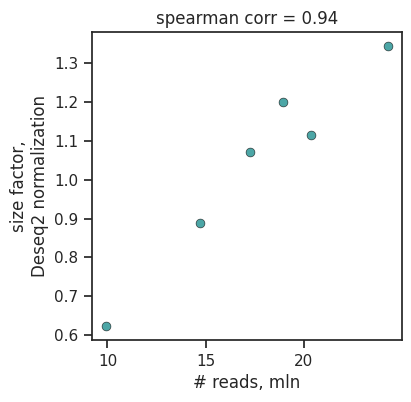

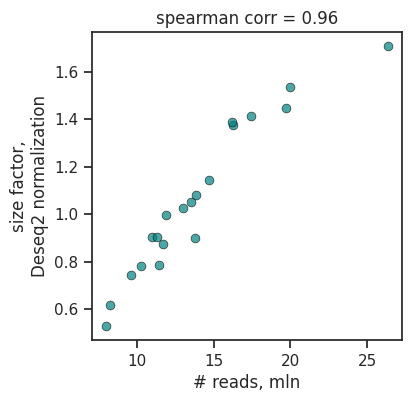

In [107]:
from zavolab_pyutils.visualization import plot_size_factors
plot_size_factors(sfs_3repl_df,savefig_path='./tests/plots/library_size_vs_SF.3repl.png')
plot_size_factors(sfs_10repl_df,savefig_path='./tests/plots/library_size_vs_SF.10repl.png')

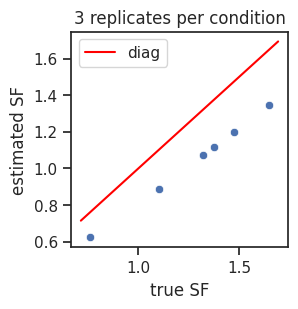

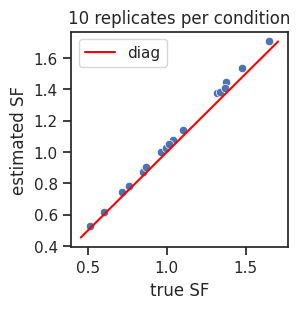

In [108]:
true_sfs = [nb_true_3repl_sf,nb_true_10repl_sf]
titles = ['3 replicates per condition','10 replicates per condition']
for k,data in enumerate([sfs_3repl_df,sfs_10repl_df]):
    data['true_sf'] = true_sfs[k]
    sns.set(font_scale=1, style="white")
    fig, axes = plt.subplots(1, 1, figsize=(2.8, 2.8))
    ax = sns.scatterplot(data = data,x='true_sf',y='sf')
    ax = sns.lineplot(data = pd.DataFrame([[ax.get_xlim()[0],ax.get_xlim()[0]],[ax.get_xlim()[1],ax.get_xlim()[1]]],columns=['true_sf','sf']),x='true_sf',y='sf',color='red',label='diag')
    ax.set(xlabel='true SF',ylabel='estimated SF',title=titles[k])
    ax.tick_params(left=True, bottom=True)

### Mean-Variance Modeling and Confidence Intervals

In [109]:
# Model the condition-specific dispersion using Quantile Regression
regr_model_3repl_df, all_plot_data_3repl_df = model_mean_variance(
    norm_counts_3repl_df, 
    metadata_3repl_df, 
    sample_col='sample', 
    cond_col='condition'
)

regr_model_10repl_df, all_plot_data_10repl_df = model_mean_variance(
    norm_counts_10repl_df, 
    metadata_10repl_df, 
    sample_col='sample', 
    cond_col='condition'
)

print("\nRegression Model Parameters (Alpha/Dispersion) for 3 replicates/condition:")
print(regr_model_3repl_df)
print("\nRegression Model Parameters (Alpha/Dispersion) for 10 replicates/condition:")
print(regr_model_10repl_df)


Regression Model Parameters (Alpha/Dispersion) for 3 replicates/condition:
   condition model_type pred_feature     param
0    Control   QuantReg          var  0.034219
1  Treatment   QuantReg          var  0.034730

Regression Model Parameters (Alpha/Dispersion) for 10 replicates/condition:
   condition model_type pred_feature     param
0    Control   QuantReg          var  0.046844
1  Treatment   QuantReg          var  0.046419


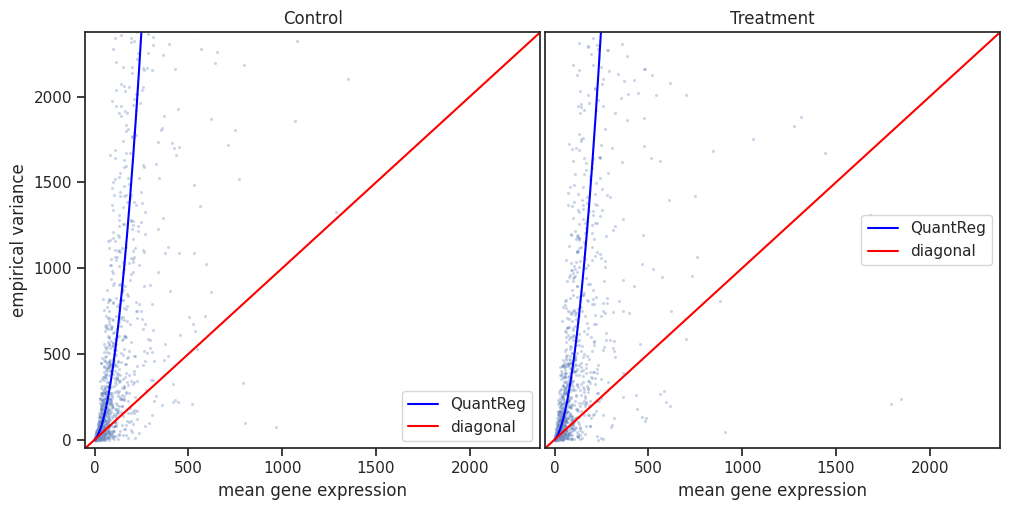

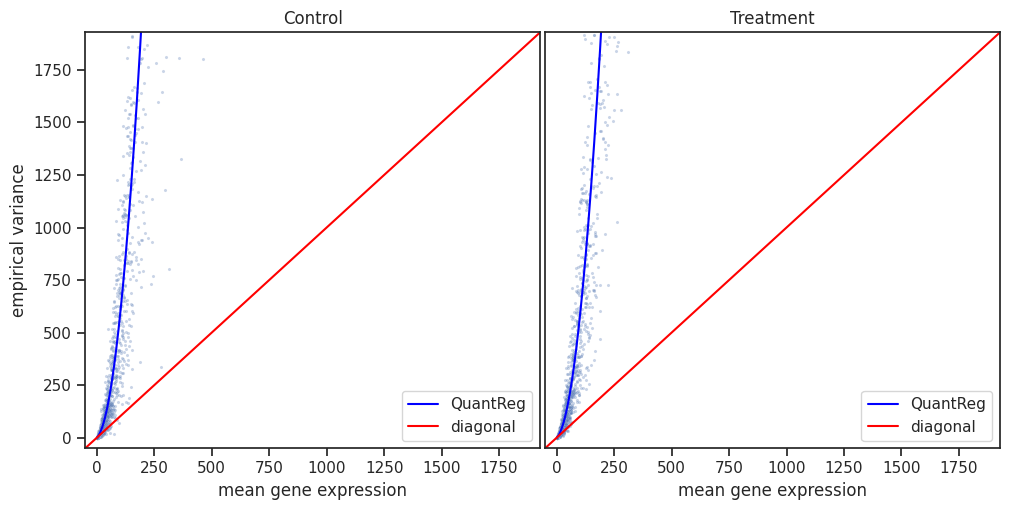

In [110]:
# Plot the diagnostic regression fits for variance within each condition
from zavolab_pyutils.visualization import plot_mean_variance_diagnostics
plot_mean_variance_diagnostics(
    all_plot_data_3repl_df, 
    savefig_path='./tests/plots/mean_variance_diagnostics.3repl.png'
)
plot_mean_variance_diagnostics(
    all_plot_data_10repl_df, 
    savefig_path='./tests/plots/mean_variance_diagnostics.10repl.png'
)

## Sanity style normalization and quantification

### First, we try to run original Sanity on simulated bulk data

we first run original Sanity from its [github repo](https://github.com/jmbreda/Sanity)

On Scicore HPC cluster, first load the necessary OpenMP module, (may be select the newest option available):
```bash
ml OpenMPI/5.0.8-GCC-14.3.0
```

In [111]:
from pathlib import Path

cmds = []
titles = ['3repl','10repl']
for k,data in enumerate([pln_counts_3repl_df,pln_counts_10repl_df]):
    cmd = "Sanity"
    sanity_format_df = data.copy()
    count_cols = list(sanity_format_df.columns)
    sanity_format_df['GeneID'] = sanity_format_df.index

    out_file_path = './tests/tables/Sanity_input_counts.'+titles[k]+'.tsv'
    dir_path = Path(out_file_path).parent
    dir_path.mkdir(parents=True, exist_ok=True)
    sanity_format_df[['GeneID']+count_cols].to_csv(out_file_path,sep=str('\t'),header=True,index=None)

    sanity_out_dir = './tests/tables/sanity_out_'+titles[k]+'/'
    dir_path = Path(sanity_out_dir)
    dir_path.mkdir(parents=True, exist_ok=True)
    cmd = cmd+" -f "+out_file_path+" -d "+sanity_out_dir+" -e true -vmin 0.0000001 -vmax 100"
    cmds.append(cmd)
print('\n'.join(cmds))

Sanity -f ./tests/tables/Sanity_input_counts.3repl.tsv -d ./tests/tables/sanity_out_3repl/ -e true -vmin 0.0000001 -vmax 100
Sanity -f ./tests/tables/Sanity_input_counts.10repl.tsv -d ./tests/tables/sanity_out_10repl/ -e true -vmin 0.0000001 -vmax 100


input counts for genes with unexpectedly high biological var, 3repl:

         Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6
GeneID                                                             
Gene_17         0         0         0         0         0         1
Gene_27         2         0         0         0         0         0
Gene_37         0         0         0         0         1         0
fraction of genes with log10 CV < -2 is 0.156, 3repl, "Control" condition
fraction of genes with log10 CV < -2 is 0.129, 10repl, "Control" condition


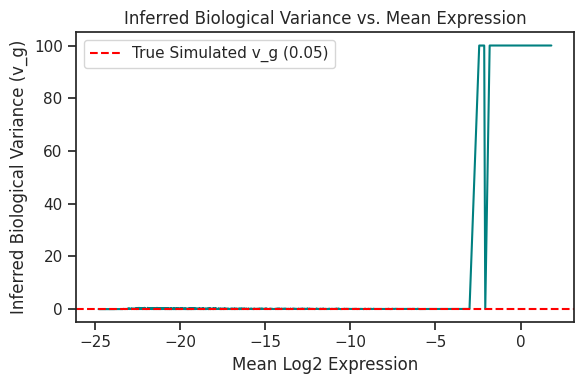

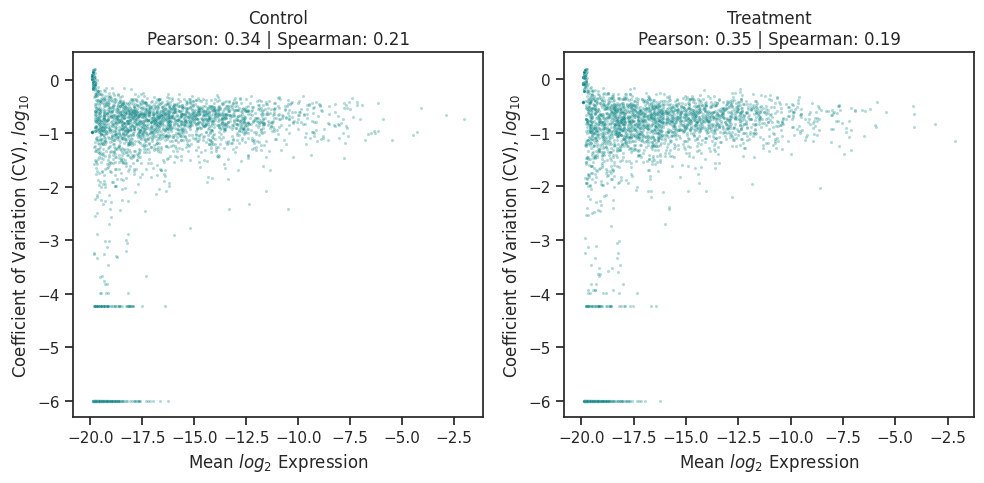

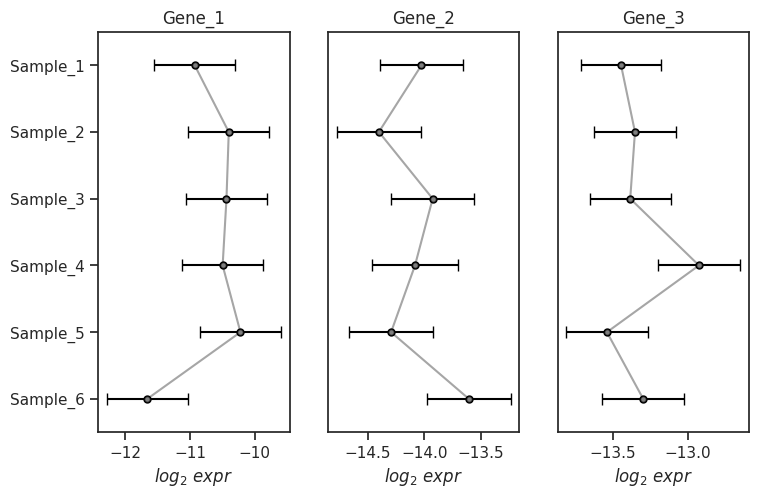

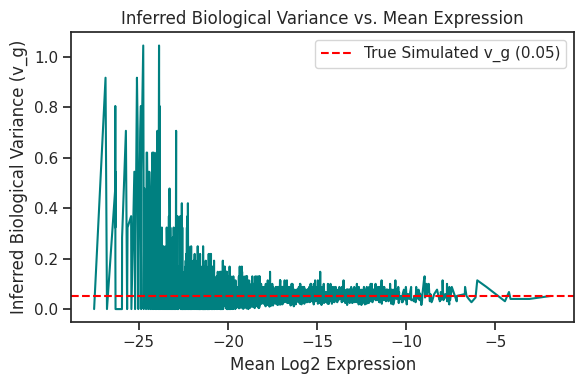

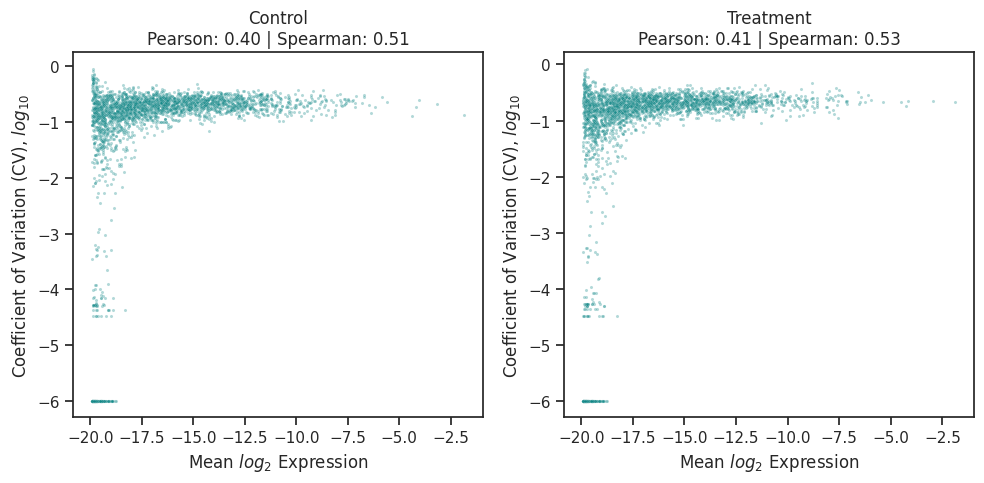

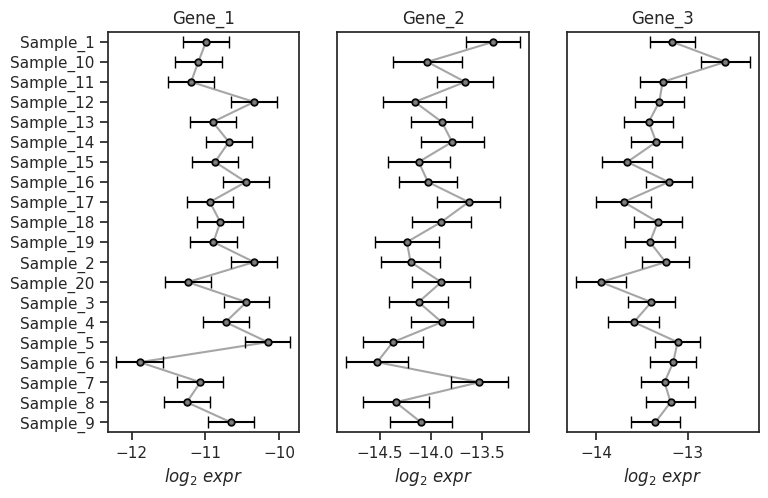

In [112]:
from zavolab_pyutils.visualization import plot_variance_vs_expression, plot_mean_vs_cv, plot_sanity_gene_expression_with_ci

replicate_options = ['3repl','10repl']
metadata_dfs = [metadata_3repl_df,metadata_10repl_df]
input_counts_dfs = [pln_counts_3repl_df,pln_counts_10repl_df]
for k,replicate_option in enumerate(replicate_options):
    Orig_sanity_norm_counts_df = pd.read_csv('./tests/tables/sanity_out_'+replicate_option+'/log_transcription_quotients_vmax.txt',delimiter="\t",index_col=0,header=0,)
    Orig_sanity_means_df = pd.read_csv('./tests/tables/sanity_out_'+replicate_option+'/mu_vmax.txt',delimiter="\t",index_col=None,header=None)
    Orig_sanity_means_df.index = Orig_sanity_norm_counts_df.index
    Orig_sanity_vg_df = pd.read_csv('./tests/tables/sanity_out_'+replicate_option+'/variance_vmax.txt',delimiter="\t",index_col=None,header=None)
    Orig_sanity_vg_df.columns = ['inferred_v_g']
    Orig_sanity_vg_df.index = Orig_sanity_norm_counts_df.index

    Orig_sanity_errors_df = pd.read_csv('./tests/tables/sanity_out_'+replicate_option+'/ltq_error_bars_vmax.txt',delimiter="\t",index_col=0,header=0,)
    log2Scale_Orig_sanity_errors_df = np.log2(np.exp(Orig_sanity_errors_df))
    
    log2Scale_Orig_sanity_means_df = np.log2(np.exp(Orig_sanity_means_df))

    genes_with_unexpectedly_high_Vg = Orig_sanity_vg_df.loc[Orig_sanity_vg_df['inferred_v_g']>50].index
    input_counts_df = input_counts_dfs[k].copy()
    if len(genes_with_unexpectedly_high_Vg)>0:
        print('input counts for genes with unexpectedly high biological var, '+replicate_option+':\n')
        print(input_counts_df.loc[genes_with_unexpectedly_high_Vg].head(3))
        
    plot_variance_vs_expression(
        log2Scale_Orig_sanity_means_df, Orig_sanity_vg_df, 
        savefig_path='./tests/plots/variance_vs_expr.Orig_Sanity.'+replicate_option+'.png',
        true_vg=0.05 # This is to compare with True value specified during simulation above
    )
    natScale_Orig_sanity_norm_counts_df = np.exp(Orig_sanity_norm_counts_df)
    Log2Scale_Orig_sanity_norm_counts_df = np.log2(natScale_Orig_sanity_norm_counts_df)
    
    Orig_sanity_plot_data = plot_mean_vs_cv(
    natScale_Orig_sanity_norm_counts_df, metadata_dfs[k], 
    savefig_path='./tests/plots/cv_plot.Orig_Sanity.'+replicate_option+'.png')

    sel_data = Orig_sanity_plot_data.loc[Orig_sanity_plot_data['condition']=='Control']
    frac_very_low_CV = len(sel_data.loc[(sel_data['log10_cv']<-2)])/len(sel_data)
    print('fraction of genes with log10 CV < -2 is '+str(np.round(frac_very_low_CV,3))+', '+replicate_option+', "Control" condition')

    selected_genes = ["Gene_1", "Gene_2", "Gene_3"]

    used_metadata_df = metadata_dfs[k].copy()
    used_metadata_df['condition'] = used_metadata_df['sample'] # in Original Sanity, there is no way to aggregate over multiple samples.
    
    plot_sanity_gene_expression_with_ci(
    sample_norm_df=Log2Scale_Orig_sanity_norm_counts_df, 
    means_df=Log2Scale_Orig_sanity_norm_counts_df, 
    errors_df=log2Scale_Orig_sanity_errors_df, 
    metadata_df=used_metadata_df, 
    selected_genes=selected_genes, 
    adjust_multiple_comparisons=True,
    
    savefig_path='./tests/plots/sanity_expression_ci.Orig_Sanity.'+replicate_option+'.png')

### We further implemented Python version for original full Bayesian Sanity

Running Full Bayesian inference on 2949 genes
Full Bayesian Sanity normalization complete.
fraction of genes with log10 CV < -2 is 0.101, 3repl, "Control" condition
not including global baseline uncertainty, FDR is 0.009, 3repl
Including global baseline uncertainty, FDR is 0.007, 3repl
Running Full Bayesian inference on 2977 genes
Full Bayesian Sanity normalization complete.
fraction of genes with log10 CV < -2 is 0.052, 10repl, "Control" condition
not including global baseline uncertainty, FDR is 0.0, 10repl
Including global baseline uncertainty, FDR is 0.0, 10repl


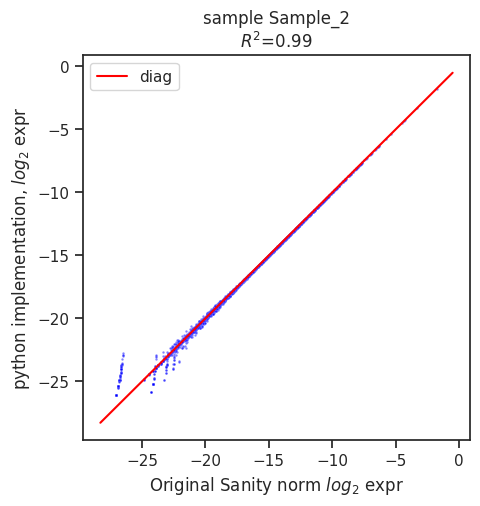

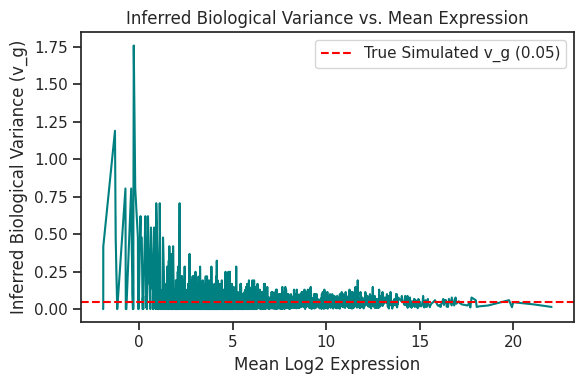

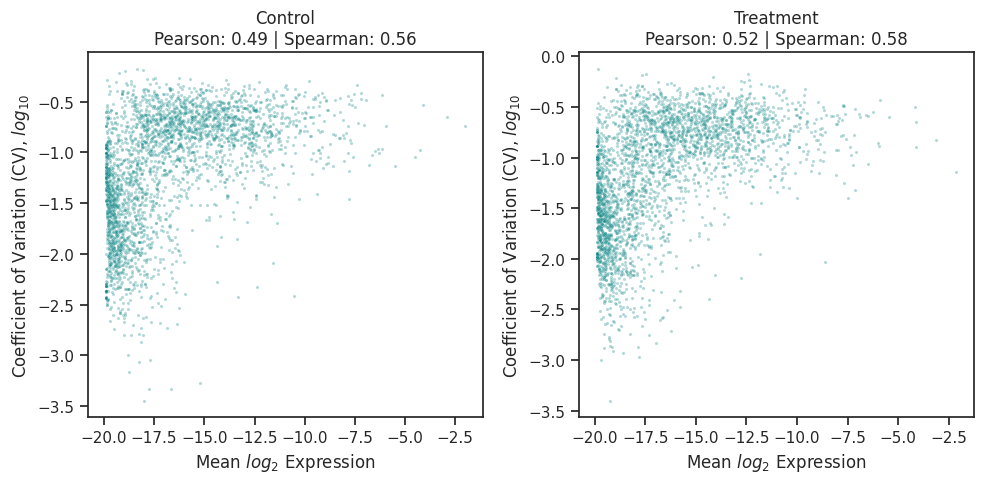

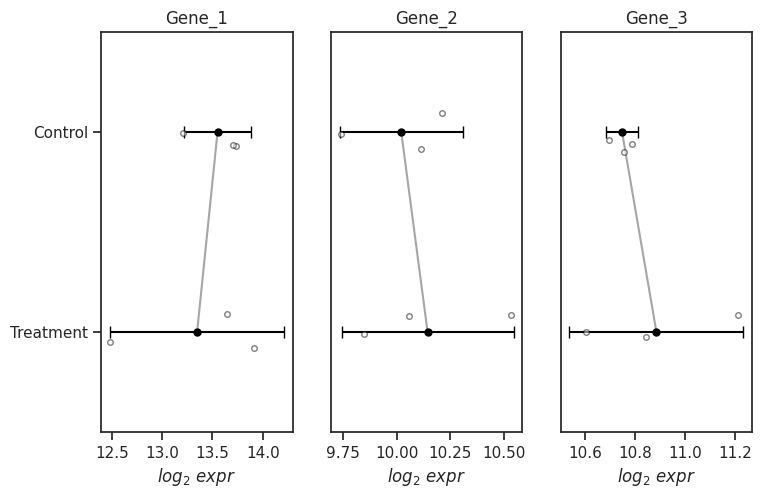

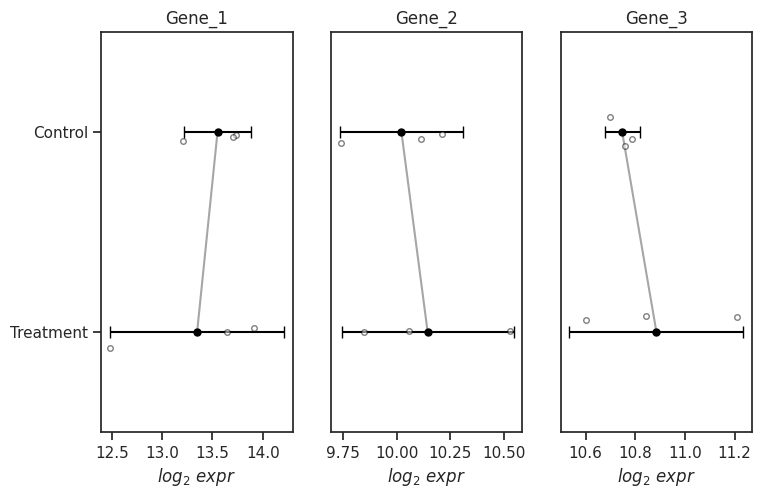

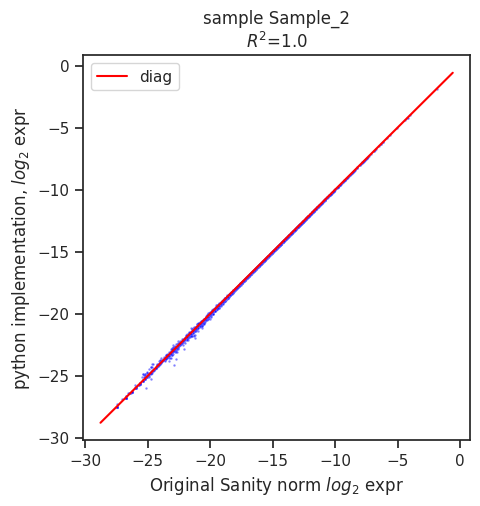

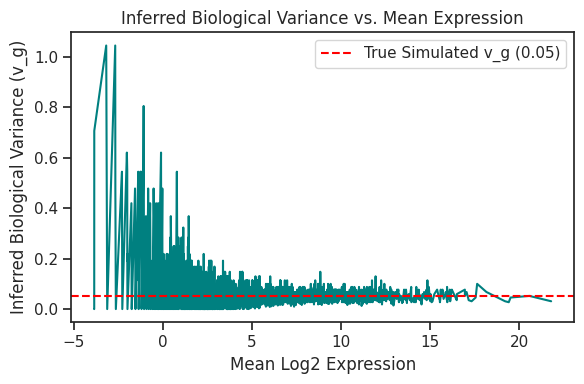

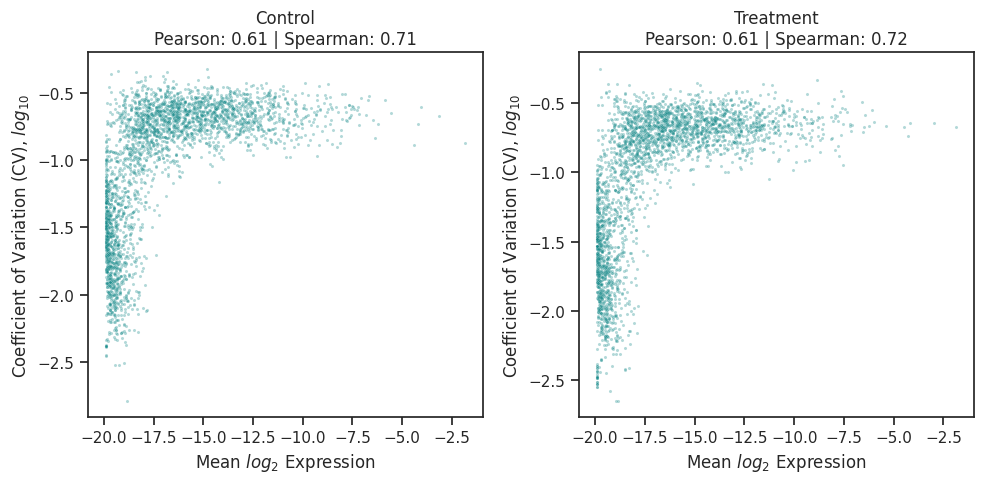

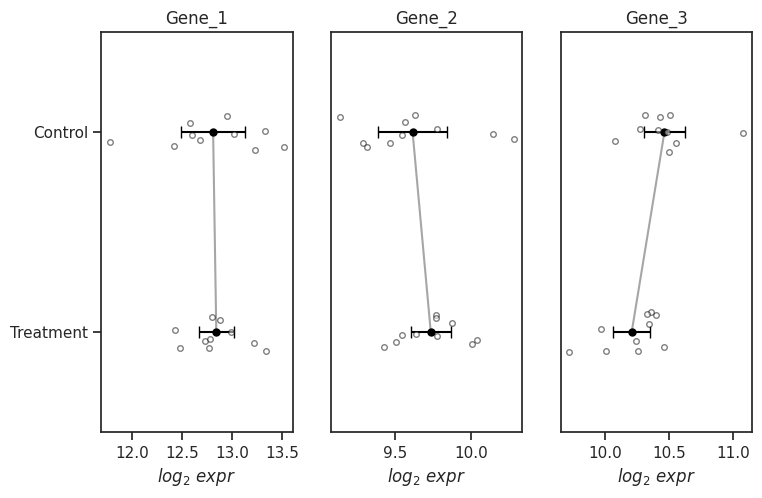

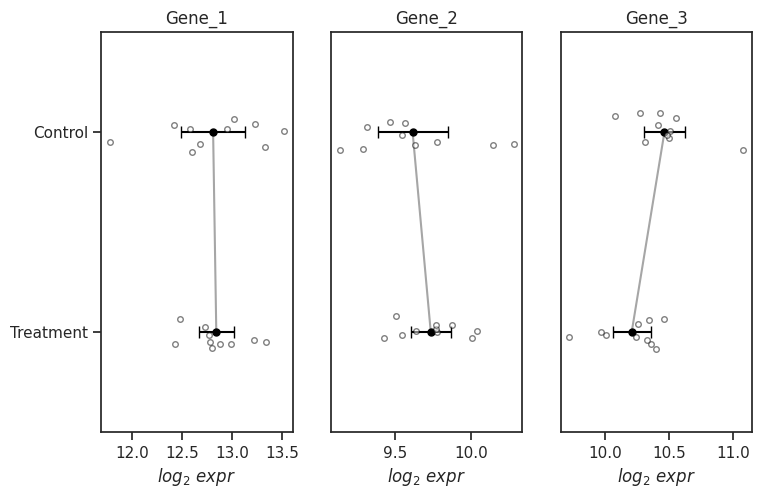

In [117]:
from zavolab_pyutils.read_count_data_analysis import apply_sanity_normalization_full_bayesian, test_differential_expression
from sklearn.metrics import r2_score

# In contrast to original Sanity implementation, we stick to log2 scale instead of natural log scale

titles = ['3repl','10repl']
metadata_dfs = [metadata_3repl_df,metadata_10repl_df]
replicate_options = ['3repl','10repl']
for k,data in enumerate([pln_counts_3repl_df,pln_counts_10repl_df]):
    sanity_norm_counts_df, sanity_means_df, sanity_relative_errors_df, sanity_absolute_errors_df, sanity_vg_df, median_lib_size, variances_df = apply_sanity_normalization_full_bayesian(
        counts_df=data.copy(), 
        metadata_df=metadata_dfs[k].copy(), 
        sample_col='sample', 
        cond_col='condition',
        vmin=0.0000001, 
        vmax=100,
        n_cores=5,
    )

    # compare with original Sanity output
    Orig_sanity_norm_counts_df = pd.read_csv('./tests/tables/sanity_out_'+replicate_options[k]+'/log_transcription_quotients_vmax.txt',delimiter="\t",index_col=0,header=0,)
    natScale_Orig_sanity_norm_counts_df = np.exp(Orig_sanity_norm_counts_df)
    Log2Scale_Orig_sanity_norm_counts_df = np.log2(natScale_Orig_sanity_norm_counts_df) # we have our output on log2 scale, and we transform original Sanity to log2 scale

    # discard the effect from library size, to directly compare with original Sanity
    ToCompare_sanity_norm_counts_df = sanity_norm_counts_df-np.log2(median_lib_size)

    sel_sample_to_compare = 'Sample_2'
    
    sns.set(font_scale=1, style="white")
    fig, axes = plt.subplots(1, 1, figsize=(5, 5))
    ax = sns.scatterplot(y=ToCompare_sanity_norm_counts_df[sel_sample_to_compare],x=Log2Scale_Orig_sanity_norm_counts_df[sel_sample_to_compare],s=3,alpha=0.5,color='blue')
    ax = sns.lineplot(data = pd.DataFrame([[ax.get_xlim()[0],ax.get_xlim()[0]],[ax.get_xlim()[1],ax.get_xlim()[1]]],columns=['true_sf','sf']),x='true_sf',y='sf',color='red',label='diag')
    
    ax.tick_params(left=True, bottom=True)

    R2val = r2_score(Log2Scale_Orig_sanity_norm_counts_df[sel_sample_to_compare],ToCompare_sanity_norm_counts_df[sel_sample_to_compare])
    ax.set(xlabel='Original Sanity norm $log_2$ expr',ylabel='python implementation, $log_2$ expr',title='sample '+sel_sample_to_compare+'\n$R^2$='+str(np.round(R2val,3)))

    sanity_vg_df['inferred_v_g'] = sanity_vg_df['MAP_v_g'] # use MAP estimate for Vg to plot, in-line with original Sanity implementation
    plot_variance_vs_expression(
        sanity_norm_counts_df, sanity_vg_df, 
        savefig_path='./tests/plots/variance_vs_expr.Python_Sanity.'+replicate_options[k]+'.png',
        true_vg=0.05 # This is to compare with True value specified during simulation above
    )

    used_metadata_df = metadata_dfs[k].copy()
    
    natScale_sanity_norm_counts_df = 2**ToCompare_sanity_norm_counts_df # with substracted median lib size, to directly compare with the plot of original Sanity above
    
    sanity_plot_data = plot_mean_vs_cv(
    natScale_sanity_norm_counts_df, used_metadata_df, 
    savefig_path='./tests/plots/cv_plot.Python_Sanity.'+replicate_options[k]+'.png')

    sel_data = sanity_plot_data.loc[sanity_plot_data['condition']=='Control']
    frac_very_low_CV = len(sel_data.loc[(sel_data['log10_cv']<-2)])/len(sel_data)
    print('fraction of genes with log10 CV < -2 is '+str(np.round(frac_very_low_CV,3))+', '+replicate_options[k]+', "Control" condition')

    selected_genes = ["Gene_1", "Gene_2", "Gene_3"]

    used_metadata_df = metadata_dfs[k].copy()

    # first, don't include global baseline uncertainty
    plot_sanity_gene_expression_with_ci(
        sample_norm_df=sanity_norm_counts_df, 
        means_df=sanity_means_df, 
        errors_df=sanity_relative_errors_df,
        metadata_df=used_metadata_df, 
        selected_genes=selected_genes, 
        adjust_multiple_comparisons=True,
        savefig_path='./tests/plots/sanity_expression_ci.Python_Sanity.'+replicate_option+'.png'
    )

    sanity_DE_df = test_differential_expression(
        means_df=sanity_means_df, 
        errors_df=sanity_relative_errors_df, 
        cond_A="Treatment", 
        cond_B="Control"
    )
    # False discovery rate is:
    FDR = len(sanity_DE_df.loc[sanity_DE_df['padj']<0.05])/len(sanity_DE_df)
    print('not including global baseline uncertainty, FDR is '+str(np.round(FDR,3))+', '+replicate_options[k])

    # second, try to include global baseline uncertainty
    plot_sanity_gene_expression_with_ci(
        sample_norm_df=sanity_norm_counts_df, 
        means_df=sanity_means_df, 
        errors_df=sanity_absolute_errors_df, # < HERE
        metadata_df=used_metadata_df, 
        selected_genes=selected_genes, 
        adjust_multiple_comparisons=True,
        savefig_path='./tests/plots/sanity_expression_ci.Python_Sanity.With_global_uncertainty.'+replicate_option+'.png'
    )

    sanity_DE_df = test_differential_expression(
        means_df=sanity_means_df, 
        errors_df=sanity_absolute_errors_df, # < HERE
        cond_A="Treatment", 
        cond_B="Control"
    )
    # False discovery rate is:
    FDR = len(sanity_DE_df.loc[sanity_DE_df['padj']<0.05])/len(sanity_DE_df)
    print('Including global baseline uncertainty, FDR is '+str(np.round(FDR,3))+', '+replicate_options[k])

In [118]:
sanity_absolute_errors_df.head()

,Control,Treatment
Gene_1,0.161545,0.090581
Gene_2,0.116437,0.067200
Gene_3,0.083052,0.075236
Gene_4,0.172129,0.172075
Gene_5,0.121874,0.139193


In [119]:
sanity_relative_errors_df.head()

,Control,Treatment
Gene_1,0.161506,0.090512
Gene_2,0.115949,0.066349
Gene_3,0.082614,0.074752
Gene_4,0.036001,0.035743
Gene_5,0.121722,0.139059


### We also implemented Empirical Bayes Shrinkage based on mean-variance relationship

PASS 1: Running Initial Full Bayesian inference on 2949 genes to estimate variances...
PASS 2: Applying Empirical Bayes Variance Shrinkage...


/scicore/home/zavolan/mirono0000/miniforge3_Dec2024/envs/zavolab_pyutils/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


Full Bayesian Sanity normalization complete.
fraction of genes with log10 CV < -2 is 0.006, 3repl, "Control" condition
FDR is 0.007, 3repl
PASS 1: Running Initial Full Bayesian inference on 2977 genes to estimate variances...
PASS 2: Applying Empirical Bayes Variance Shrinkage...


/scicore/home/zavolan/mirono0000/miniforge3_Dec2024/envs/zavolab_pyutils/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


Full Bayesian Sanity normalization complete.
fraction of genes with log10 CV < -2 is 0.0, 10repl, "Control" condition
FDR is 0.0, 10repl


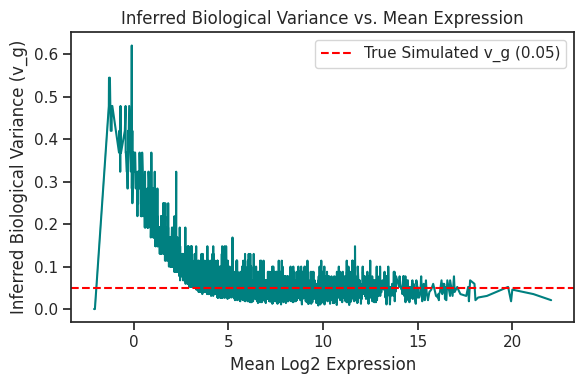

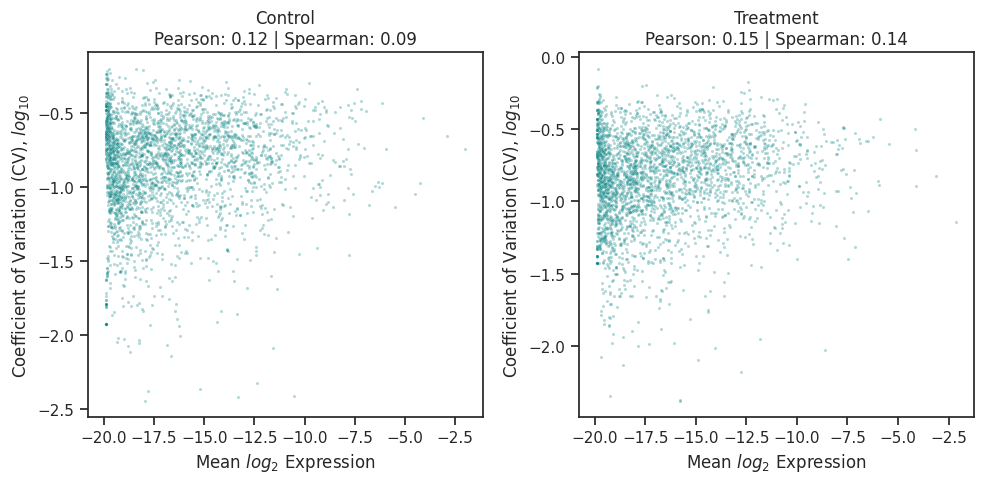

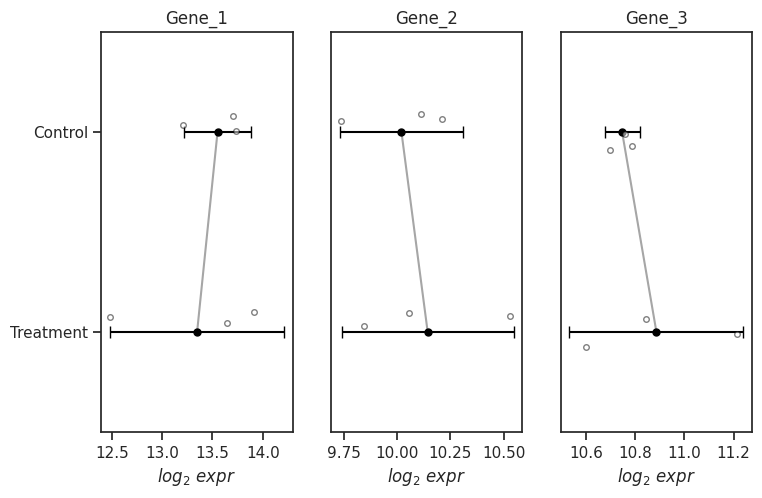

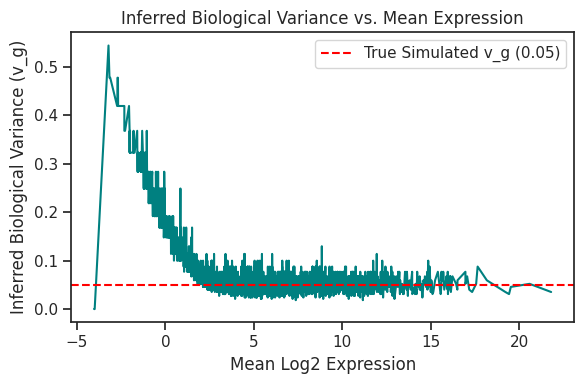

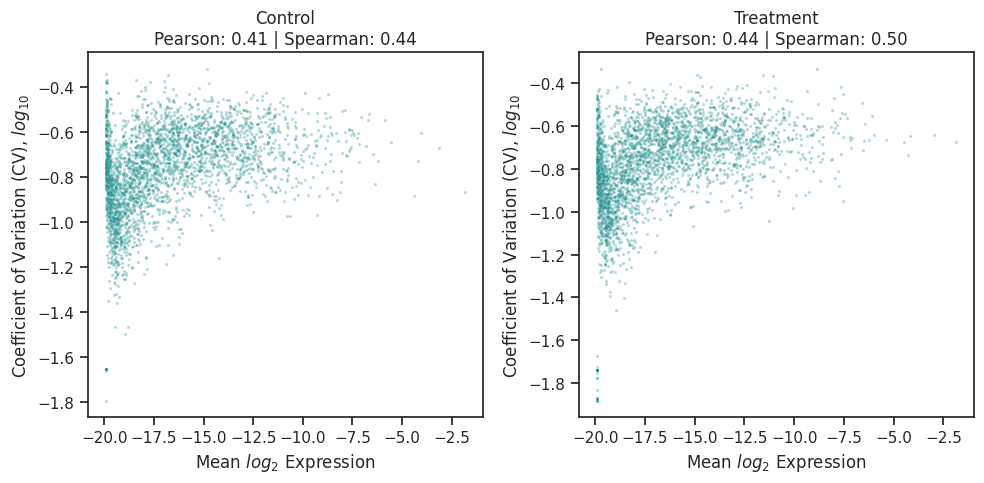

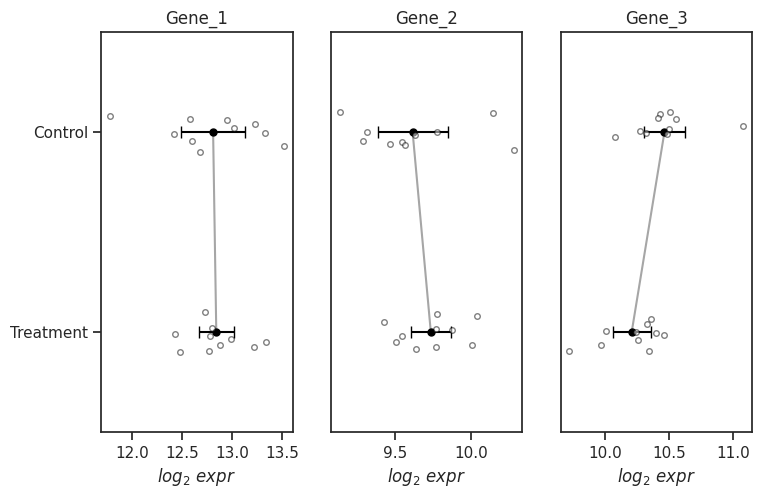

In [122]:
from zavolab_pyutils.read_count_data_analysis import apply_sanity_normalization_full_bayesian, test_differential_expression
from sklearn.metrics import r2_score

# In contrast to original Sanity implementation, we stick to log2 scale instead of natural log scale

titles = ['3repl','10repl']
metadata_dfs = [metadata_3repl_df,metadata_10repl_df]
replicate_options = ['3repl','10repl']
for k,data in enumerate([pln_counts_3repl_df,pln_counts_10repl_df]):
    sanity_norm_counts_df, sanity_means_df, sanity_relative_errors_df, sanity_absolute_errors_df, sanity_vg_df, median_lib_size, variances_df = apply_sanity_normalization_full_bayesian(
        counts_df=data.copy(), 
        metadata_df=metadata_dfs[k].copy(), 
        sample_col='sample', 
        cond_col='condition',
        vmin=0.0000001, 
        vmax=100,
        n_cores=5,
        empirical_bayes=True, # NOTE, here!
    )

    # discard the effect from library size, as above
    ToCompare_sanity_norm_counts_df = sanity_norm_counts_df-np.log2(median_lib_size)

    sanity_vg_df['inferred_v_g'] = sanity_vg_df['MAP_v_g'] # use MAP estimate for Vg to plot, in-line with original Sanity implementation
    plot_variance_vs_expression(
        sanity_norm_counts_df, sanity_vg_df, 
        savefig_path='./tests/plots/variance_vs_expr.Python_EBS_Sanity.'+replicate_options[k]+'.png',
        true_vg=0.05 # This is to compare with True value specified during simulation above
    )

    used_metadata_df = metadata_dfs[k].copy()
    
    natScale_sanity_norm_counts_df = 2**ToCompare_sanity_norm_counts_df # with substracted median lib size, to directly compare with the plot of original Sanity above
    
    sanity_plot_data = plot_mean_vs_cv(
    natScale_sanity_norm_counts_df, used_metadata_df, 
    savefig_path='./tests/plots/cv_plot.Python_EBS_Sanity.'+replicate_options[k]+'.png')

    sel_data = sanity_plot_data.loc[sanity_plot_data['condition']=='Control']
    frac_very_low_CV = len(sel_data.loc[(sel_data['log10_cv']<-2)])/len(sel_data)
    print('fraction of genes with log10 CV < -2 is '+str(np.round(frac_very_low_CV,3))+', '+replicate_options[k]+', "Control" condition')

    selected_genes = ["Gene_1", "Gene_2", "Gene_3"]

    used_metadata_df = metadata_dfs[k].copy()
    
    plot_sanity_gene_expression_with_ci(
    sample_norm_df=sanity_norm_counts_df, 
    means_df=sanity_means_df, 
    errors_df=sanity_absolute_errors_df, 
    metadata_df=used_metadata_df, 
    selected_genes=selected_genes, 
    adjust_multiple_comparisons=True,
    savefig_path='./tests/plots/sanity_expression_ci.Python_EBS_Sanity.'+replicate_option+'.png')

    sanity_DE_df = test_differential_expression(
        means_df=sanity_means_df, 
        errors_df=sanity_absolute_errors_df, # include global uncertainty to be a bit more conservative
        cond_A="Treatment", 
        cond_B="Control"
    )
    # False discovery rate is:
    FDR = len(sanity_DE_df.loc[sanity_DE_df['padj']<0.05])/len(sanity_DE_df)
    print('FDR is '+str(np.round(FDR,3))+', '+replicate_options[k])

## We further implemented post-hoc test for differential isoform usage

In [81]:
# we generate the data under assumption of NO differentially expressed genes, so any significant changes between conditions are false positives!
# but, we can have differentially used isoforms!

PASS 1: Running Initial Full Bayesian inference on 13707 genes to estimate variances...
PASS 2: Applying Empirical Bayes Variance Shrinkage...


/scicore/home/zavolan/mirono0000/miniforge3_Dec2024/envs/zavolab_pyutils/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


Full Bayesian Sanity normalization complete.
fraction of isoforms with log10 CV < -2 is 0.034, 3repl, "Control" condition
fraction of isoforms+REST with log10 CV < -2 is 0.029, 3repl, "Control" condition
FDR is 0.001, 3repl
PASS 1: Running Initial Full Bayesian inference on 14690 genes to estimate variances...
PASS 2: Applying Empirical Bayes Variance Shrinkage...


/scicore/home/zavolan/mirono0000/miniforge3_Dec2024/envs/zavolab_pyutils/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


Full Bayesian Sanity normalization complete.
fraction of isoforms with log10 CV < -2 is 0.0, 10repl, "Control" condition
fraction of isoforms+REST with log10 CV < -2 is 0.0, 10repl, "Control" condition
FDR is 0.0, 10repl


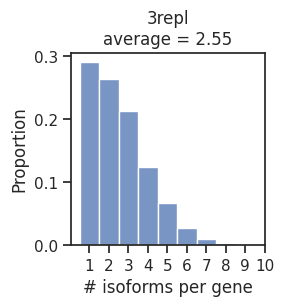

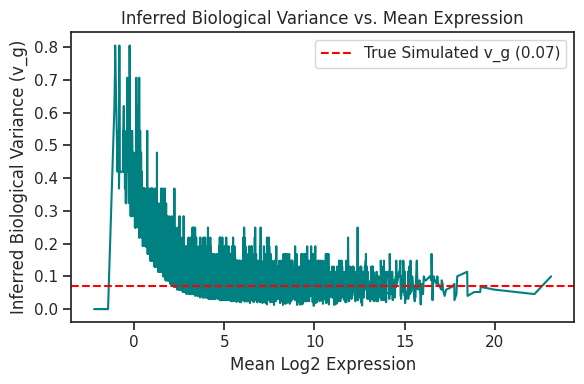

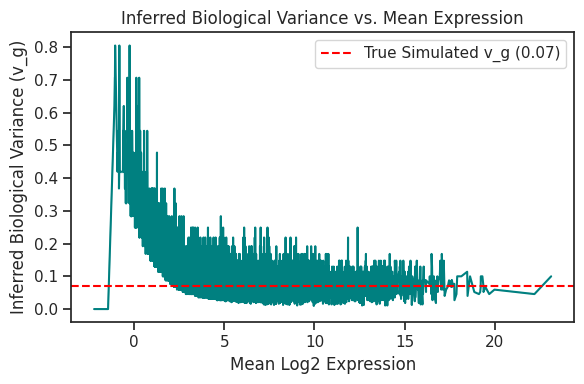

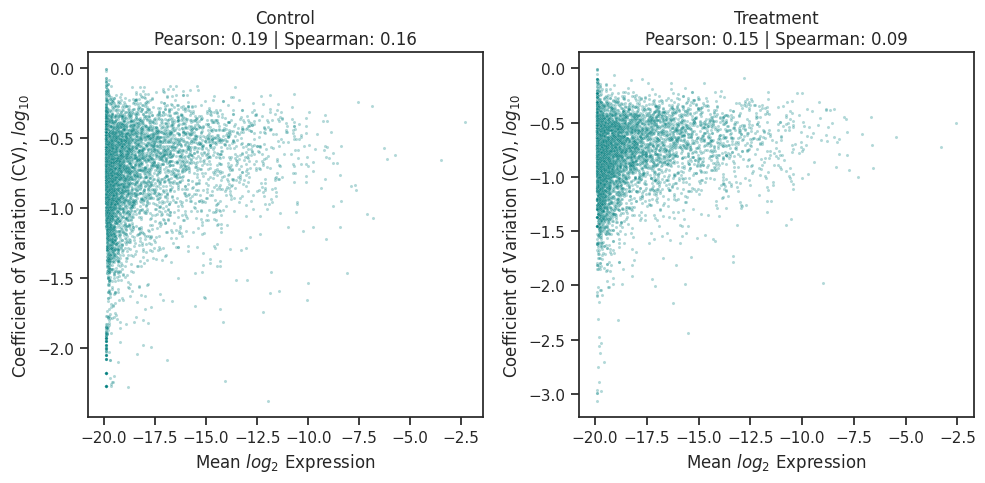

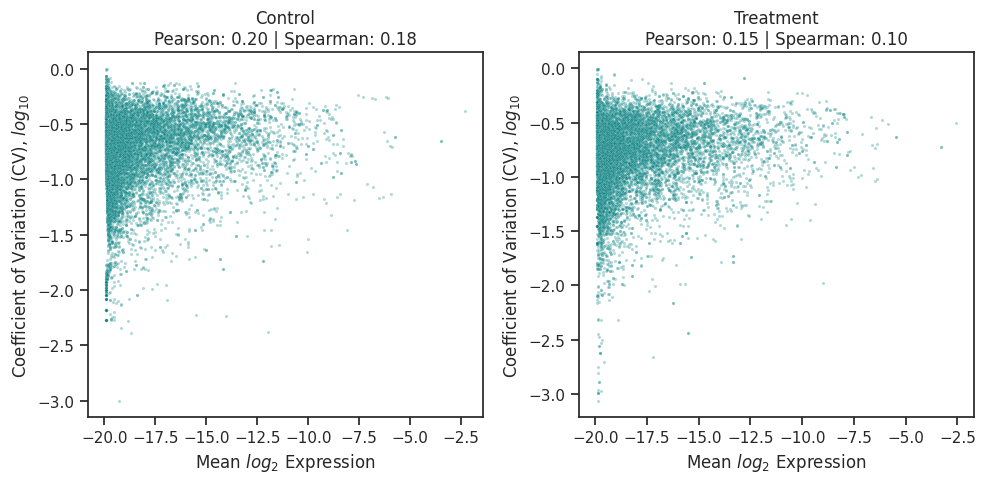

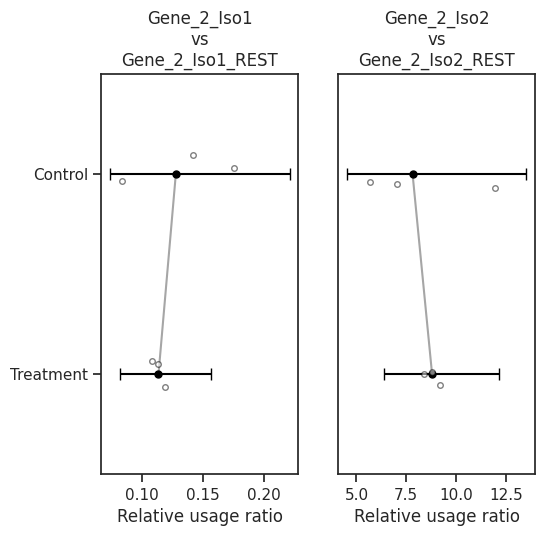

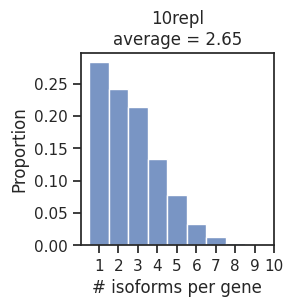

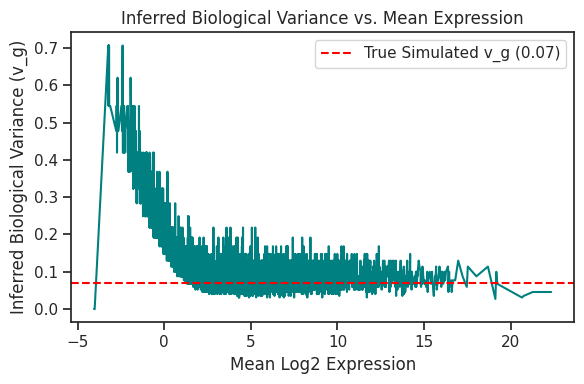

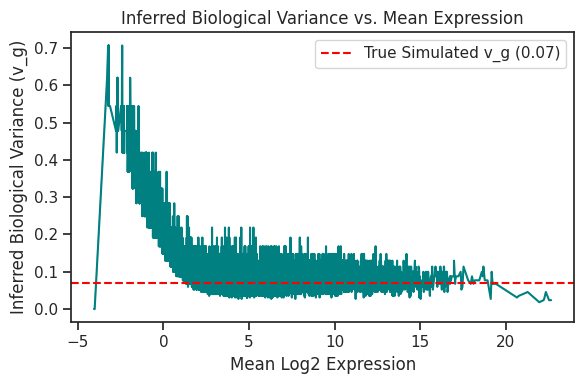

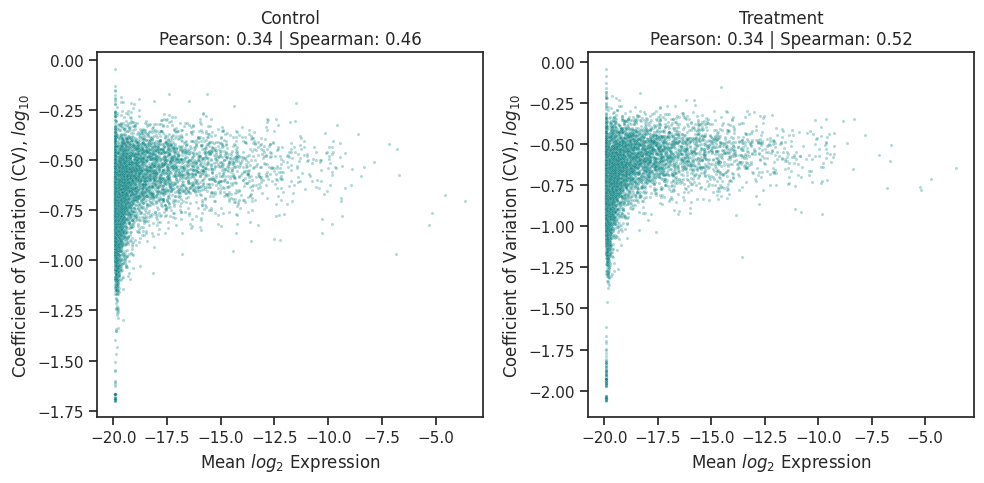

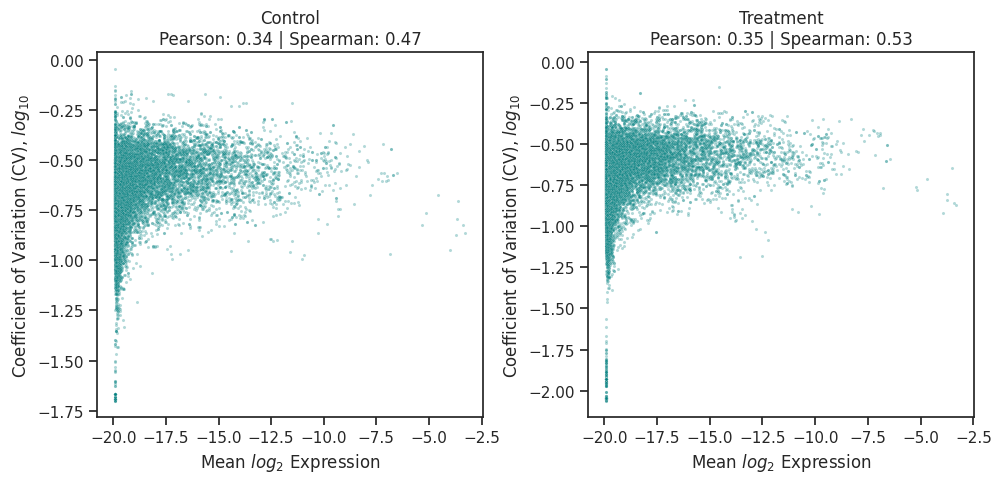

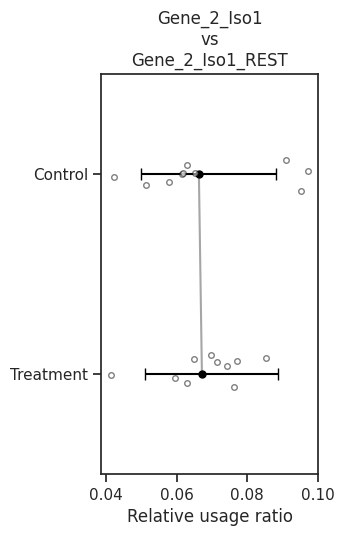

In [172]:
from zavolab_pyutils.read_count_simulation import simulate_isoform_negative_binomial_counts, simulate_isoform_poisson_lognormal_counts

from zavolab_pyutils.read_count_data_analysis import (
    prepare_isoform_sanity_matrix, 
    apply_sanity_normalization_full_bayesian, 
    test_differential_relative_usage
)
from zavolab_pyutils.visualization import plot_sanity_relative_usage_with_ci, plot_variance_vs_expression,plot_mean_vs_cv

replicate_options = ['3repl','10repl']
number_of_replicates = [3,10]
for k,replicate_option in enumerate(replicate_options):
    
    iso_counts_df, metadata_df, isoform_to_gene_dict, diff_genes = simulate_isoform_poisson_lognormal_counts(
        N_genes=3000, conditions=["Control", "Treatment"],
        n_replicates=number_of_replicates[k], 
        v_log_gene=0.05, v_log_iso=0.02, seed=42, 
        SF_sigma=0.3, exp_average_M=4, exp_average_S=3, frac_diff_usage=0,
        lambda_iso=2.5, shift_logfc_mean=0.0, shift_logfc_sd=1.0,
    )
    
    isoform_to_gene_df = pd.DataFrame.from_dict(isoform_to_gene_dict,orient='index',columns = ['gene_name'])

    # check how many isoforms were simulated
    isoform_to_gene_df['t']=1
    gr = isoform_to_gene_df.groupby('gene_name').agg({'t':np.sum}).reset_index()
    
    sns.set(font_scale=1, style="white")
    fig, axes = plt.subplots(1, 1, figsize=(2.5, 2.5))
    ax = sns.histplot(gr['t'],stat='proportion',bins=np.arange(0.01,10.01,1))
    ax.set(xlabel='# isoforms per gene',xticks=np.arange(0.5,10.5,1),xticklabels = np.arange(1,11,1),title=replicate_option+'\naverage = '+str(np.round(gr['t'].mean(),2)))
    ax.tick_params(left=True, bottom=True)
    
    # 1. Prepare Augmented Data (Isoforms + Rest of Gene)
    augmented_raw_counts, target_pairs = prepare_isoform_sanity_matrix(
        iso_counts_df=iso_counts_df, 
        isoform_to_gene=isoform_to_gene_dict
    )
    
    # 2. Run Sanity on the augmented matrix
    # This infers the posteriors for both the isoforms AND their specific "Rest" pools simultaneously
    sanity_norm_counts_df, sanity_means_df, sanity_relative_errors_df, sanity_absolute_errors_df, sanity_vg_df, median_lib_size, variances_df = apply_sanity_normalization_full_bayesian(
        counts_df=augmented_raw_counts,
        metadata_df=metadata_df, 
        sample_col='sample', 
        cond_col='condition',
        vmin=0.0000001, vmax=100, n_cores=8,
        empirical_bayes=True,
    )

    # 3. Run diagnostic plots
    ToCompare_sanity_norm_counts_df = sanity_norm_counts_df-np.log2(median_lib_size)
    
    sanity_vg_df['inferred_v_g'] = sanity_vg_df['MAP_v_g'] # use MAP estimate for Vg to plot, in-line with original Sanity implementation

    ISOonly_sanity_vg_df = sanity_vg_df.loc[~sanity_vg_df.index.str.endswith('_REST')]
    ISOonly_sanity_norm_counts_df = sanity_norm_counts_df.loc[~sanity_norm_counts_df.index.str.endswith('_REST')]
    
    plot_variance_vs_expression(
        ISOonly_sanity_norm_counts_df, ISOonly_sanity_vg_df, 
        savefig_path='./tests/plots/variance_vs_expr.Python_EBS_Sanity.Isoforms.'+replicate_option+'.png',
        true_vg=0.05 + 0.02, # This is to compare with True value specified during simulation above, we sum up true gene-level noise and isoform-level noise
    )

    plot_variance_vs_expression(
        sanity_norm_counts_df, sanity_vg_df, 
        savefig_path='./tests/plots/variance_vs_expr.Python_EBS_Sanity.Isoforms_and_REST.'+replicate_option+'.png',
        true_vg=0.05 + 0.02, # This is to compare with True value specified during simulation above, we sum up true gene-level noise and isoform-level noise
    )
    
    used_metadata_df = metadata_df.copy()

    natScale_sanity_norm_counts_df = 2**ToCompare_sanity_norm_counts_df # with substracted median lib size, to directly compare with the plot of original Sanity above

    # first, try for isoform expression-only
    ISOonly_natScale_sanity_norm_counts_df = natScale_sanity_norm_counts_df.loc[~natScale_sanity_norm_counts_df.index.str.endswith('_REST')]
    
    sanity_plot_data = plot_mean_vs_cv(
    ISOonly_natScale_sanity_norm_counts_df.copy(), used_metadata_df, 
    savefig_path='./tests/plots/cv_plot.Python_EBS_Sanity.Isoforms.'+replicate_option+'.png')
    
    sel_data = sanity_plot_data.loc[sanity_plot_data['condition']=='Control']
    frac_very_low_CV = len(sel_data.loc[(sel_data['log10_cv']<-2)])/len(sel_data)
    print('fraction of isoforms with log10 CV < -2 is '+str(np.round(frac_very_low_CV,3))+', '+replicate_option+', "Control" condition')

    # second, include REST counts as well
    
    sanity_plot_data = plot_mean_vs_cv(
    natScale_sanity_norm_counts_df.copy(), used_metadata_df, 
    savefig_path='./tests/plots/cv_plot.Python_EBS_Sanity.Isoforms_and_REST.'+replicate_option+'.png')
    
    sel_data = sanity_plot_data.loc[sanity_plot_data['condition']=='Control']
    frac_very_low_CV = len(sel_data.loc[(sel_data['log10_cv']<-2)])/len(sel_data)
    print('fraction of isoforms+REST with log10 CV < -2 is '+str(np.round(frac_very_low_CV,3))+', '+replicate_option+', "Control" condition')

    # 4. Test for Differential Relative Usage (Isoform Fraction shifts)
    res_df = test_differential_relative_usage(
        norm_counts_df=sanity_norm_counts_df.copy(), 
        variances_df=variances_df, 
        metadata_df=metadata_df, 
        isoform_pairs=target_pairs, # Testing Isoform vs Rest
        cond_A='Treatment', 
        cond_B='Control'
    )
    # False discovery rate is:
    FDR = len(res_df.loc[res_df['padj']<0.05])/len(res_df)
    print('FDR is '+str(np.round(FDR,3))+', '+replicate_option)

    # 4. Plot the relative usage (Log-Odds of the fraction)
    plot_sanity_relative_usage_with_ci(
        norm_counts_df=sanity_norm_counts_df.copy(), 
        variances_df=variances_df, 
        metadata_df=metadata_df, 
        isoform_pairs=target_pairs[0:3], # Pass the top pair to visualize
        savefig_path='./tests/plots/relative_usage_CI.Python_EBS_Sanity.'+replicate_option+'.png',
        log2_scale=False,
    )    